<a href="https://colab.research.google.com/github/henriquerrodrigues/Projeto-ML-Seguranca/blob/sprint2/notebooks/ML_Sinistros_Rodovias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

In [ ]:
# Pasta de trabalho local (repo root, já commitada — ver ingest_prf_sc.py na raiz)
DATA_DIR = Path("../data_prf_sc")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"

# Anos a baixar (agrupados por ocorrência). Ajuste conforme necessário —
# quanto mais anos, mais volume para o treino, mas atenção a mudanças de
# metodologia de coleta da PRF ao longo do tempo.
GDRIVE_FILE_IDS: dict[int, str] = {
    # 2026: "1A3IirNm0AzRaSosA1IS94DOVmvKsn0Ol",
    2025: "1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR",
    2024: "14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO",
    2023: "1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq",
    2022: "1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-",
    2021: "12xH8LX9aN2gObR766YN3cMcuycwyCJDz",
    2020: "1esu6IiH5TVTxFoedv6DBGDd01Gvi8785",
    # 2019: "1pN3fn2wY34GH6cY-gKfbxRJJBFE0lb_l",
    # 2018: "1cM4IgGMIiR-u4gBIH5IEe3DcvBvUzedi",
    # 2017: "1HPLWt5f_l4RIX3tKjI4tUXyZOev52W0N",
}

UF_ALVO = "SC"

# Aponte aqui para a planilha do SNV baixada manualmente do DNIT/VGEO
SNV_LOCAL_PATH = DATA_DIR / "snv_base.csv"  # .xls também funciona, ver load_snv()

FINAL_OUTPUT_PATH = OUT_DIR / "sinistros_sc_todas_brs.csv"

In [ ]:
def download_prf_year(year: int, file_id: str, dest_dir: Path) -> Path:
    """Baixa o CSV de um ano via gdown (lida com a tela de confirmação do Drive)."""
    import gdown

    dest_dir.mkdir(parents=True, exist_ok=True)
    dest = dest_dir / f"acidentes{year}.csv"
    if dest.exists():
        print(f"[{year}] já baixado, pulando.")
        return dest

    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"[{year}] baixando...")
    gdown.download(url, str(dest), quiet=False)
    return dest

In [ ]:
import re

def read_prf_csv(path: Path) -> pd.DataFrame:
    """Le CSV da PRF. Arquivo do Drive vem como .zip (mesmo com extensao .csv
    no nome), às vezes contendo o csv dentro de uma subpasta (ex.: datatran2026/
    datatran2026.csv) — por isso não dá pra usar compression="zip" direto, que
    só aceita zip com um único membro. Extraímos o .csv manualmente."""
    import zipfile

    with open(path, "rb") as f:
        is_zip = f.read(2) == b"PK"

    if is_zip:
        with zipfile.ZipFile(path) as zf:
            csv_names = [n for n in zf.namelist() if n.lower().endswith(".csv")]
            if not csv_names:
                raise ValueError(f"Nenhum .csv encontrado dentro do zip {path}")
            with zf.open(csv_names[0]) as fh:
                return pd.read_csv(
                    fh, sep=";", encoding="latin1", decimal=",", low_memory=False
                )

    return pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        decimal=",",
        low_memory=False,
    )


def normalize_prf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nomes de coluna: minusculas, sem espaco/acento nas bordas."""
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.replace(" ", "_", regex=False)
    )
    return df


def _to_nullable_int(series: pd.Series) -> pd.Series:
    """Converte identificadores para inteiro com suporte a nulos."""
    normalized = (
        series.astype(str)
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        .str.replace(r"\.0+$", "", regex=True)
        .str.extract(r"(-?\d+)", expand=False)
    )
    return pd.to_numeric(normalized, errors="coerce").astype("Int64")


def _clean_decimal_text(value: object) -> str:
    text = str(value).strip()
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if "," in text and "." in text:
        # Usa como decimal o último separador; os demais viram milhares.
        comma_pos = text.rfind(",")
        dot_pos = text.rfind(".")
        decimal_sep = "," if comma_pos > dot_pos else "."
        thousands_sep = "." if decimal_sep == "," else ","
        text = text.replace(thousands_sep, "")
        text = text.replace(decimal_sep, ".")
    elif "," in text:
        text = text.replace(",", ".")
    return text


def _coerce_coord_value(value: object, limit: float) -> float | None:
    if pd.isna(value):
        return None

    text = _clean_decimal_text(value)
    if text in {"", "+", "-", ".", "+.", "-."}:
        return None

    parsed = pd.to_numeric(text, errors="coerce")
    if pd.isna(parsed):
        return None

    number = float(parsed)
    if abs(number) <= limit:
        return number

    digits = re.sub(r"\D", "", text)
    if not digits:
        return None
    sign = -1 if text.startswith("-") else 1
    scaled = float(int(digits)) * sign
    while abs(scaled) > limit and scaled != 0:
        scaled /= 10.0
    return scaled if abs(scaled) <= limit else None


def normalize_prf_values(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza tipos sensíveis (id, km, br, latitude, longitude)."""
    df = df.copy()

    for id_col in ("id", "id_acidente"):
        if id_col in df.columns:
            df[id_col] = _to_nullable_int(df[id_col])

    if "km" in df.columns:
        df["km"] = pd.to_numeric(
            df["km"].astype(str).str.replace(",", ".", regex=False),
            errors="coerce",
        )

    if "br" in df.columns:
        df["br"] = pd.to_numeric(
            df["br"].astype(str).str.extract(r"(\d+)", expand=False),
            errors="coerce",
        ).astype("Int64")

    if "latitude" in df.columns:
        df["latitude"] = df["latitude"].map(lambda value: _coerce_coord_value(value, 90.0))
    if "longitude" in df.columns:
        df["longitude"] = df["longitude"].map(lambda value: _coerce_coord_value(value, 180.0))

    if "br" in df.columns:
        df["fora_br"] = df["br"].fillna(-1).eq(0)
        df["relevancia_rodovia"] = df["fora_br"].map(
            {True: "baixa (fora de BR)", False: "alta (em BR)"}
        )

    return df

In [ ]:
# Rodovias Federais oficiais com malha operacional e volume representativo em SC
# (Descarta BR 0, BR 285 com 14 acidentes em obras, e BRs 477 e 475 com 1 ocorrência apenas)
BRS_VALIDAS_SC = [101, 282, 470, 280, 116, 163, 153, 480, 158, 285]

def filter_sc_brs(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "km" in df.columns:
        df["km"] = pd.to_numeric(
            df["km"].astype(str).str.replace(",", ".", regex=False), errors="coerce"
        )
    if "br" in df.columns:
        df["br"] = pd.to_numeric(df["br"], errors="coerce")

    mask = pd.Series(True, index=df.index)
    if "uf" in df.columns:
        mask &= df["uf"].astype(str).str.upper().str.strip() == UF_ALVO
    # Mantém estritamente as 9 BRs válidas
    if "br" in df.columns:
        mask &= df["br"].isin(BRS_VALIDAS_SC)
    return df[mask].reset_index(drop=True)


In [ ]:
def load_snv(path: Path) -> pd.DataFrame:
    """
    Carrega a planilha do SNV. Ajuste os nomes de coluna abaixo conforme a
    versão baixada (eles variam um pouco entre releases do DNIT).
    Colunas esperadas após normalização: br, uf, km_inicial, km_final,
    superficie, jurisdicao (algumas dessas podem não existir — trate como opcional).
    """
    if not path.exists():
        print(
            f"[aviso] {path} não encontrado — pulando o merge com o SNV. "
            "Baixe a planilha do DNIT/VGEO e aponte SNV_LOCAL_PATH para rodar essa etapa."
        )
        return pd.DataFrame()

    if path.suffix.lower() in {".xls", ".xlsx"}:
        snv = pd.read_excel(path)
    else:
        snv = pd.read_csv(path, sep=None, engine="python")

    snv = normalize_prf_columns(snv)  # mesma limpeza de nomes serve aqui
    return snv


def merge_with_snv(acidentes: pd.DataFrame, snv: pd.DataFrame) -> pd.DataFrame:
    """
    Casa cada acidente ao trecho do SNV cujo intervalo [km_inicial, km_final]
    contém o km do acidente, para o mesmo BR/UF.
    """
    if snv.empty or "km" not in acidentes.columns:
        return acidentes

    required = {"br", "uf", "km_inicial", "km_final"}
    missing = required - set(snv.columns)
    if missing:
        print(f"[aviso] SNV sem as colunas {missing} — confira os nomes reais e ajuste load_snv(). Pulando merge.")
        return acidentes

    snv = snv.copy()
    snv["br"] = pd.to_numeric(snv["br"], errors="coerce")
    snv["km_inicial"] = pd.to_numeric(snv["km_inicial"], errors="coerce")
    snv["km_final"] = pd.to_numeric(snv["km_final"], errors="coerce")

    merged_rows = []
    for (uf, br), grp_acid in acidentes.groupby(["uf", "br"]):
        grp_snv = snv[(snv["uf"].astype(str).str.upper() == str(uf).upper()) & (snv["br"] == br)]
        if grp_snv.empty:
            merged_rows.append(grp_acid)
            continue

        grp_snv = grp_snv.sort_values("km_inicial")
        acids = grp_acid.copy()
        acids["_snv_idx"] = acids["km"].apply(
            lambda k: _find_segment(k, grp_snv) if pd.notnull(k) else None
        )
        acids = acids.merge(
            grp_snv.drop(columns=["br", "uf"]).add_prefix("snv_"),
            left_on="_snv_idx",
            right_index=True,
            how="left",
        ).drop(columns=["_snv_idx"])
        merged_rows.append(acids)

    return pd.concat(merged_rows, ignore_index=True) if merged_rows else acidentes


def _find_segment(km: float, snv_group: pd.DataFrame):
    match = snv_group[(snv_group["km_inicial"] <= km) & (km <= snv_group["km_final"])]
    return match.index[0] if not match.empty else None

## Arquivo Main()

cria as pastas e faz o download das planilhas faltantes
dataset final pronto pra EDA, sinistros de SC em todas as BRs, ano a ano.

In [ ]:
def main() -> None:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    FINAL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

    frames = []
    for year, file_id in sorted(GDRIVE_FILE_IDS.items()):
        try:
            path = download_prf_year(year, file_id, RAW_DIR)
            df = read_prf_csv(path)
            df = normalize_prf_columns(df)
            df["ano_arquivo"] = year
            df_sc = filter_sc_brs(df)
            print(f"[{year}] {len(df)} registros nacionais -> {len(df_sc)} em SC/todas as BRs")
            frames.append(df_sc)
        except Exception as e:  # noqa: BLE001
            print(f"[{year}] ERRO: {e}", file=sys.stderr)

    if not frames:
        print("Nenhum ano foi processado com sucesso. Abortando.")
        return

    acidentes = pd.concat(frames, ignore_index=True)
    interim_path = OUT_DIR / "acidentes_sc_todas_brs_bruto.csv"
    acidentes.to_csv(interim_path, index=False, decimal=",")
    print(f"\nBase filtrada (sem merge SNV) salva em: {interim_path} ({len(acidentes)} linhas)")

    br_summary = (
        acidentes.groupby("br", dropna=False)
        .size()
        .rename("quantidade_acidentes")
        .reset_index()
        .sort_values("br", na_position="last")
    )
    br_summary.to_csv(OUT_DIR / "brs_sc_resumo.csv", index=False)
    print(f"Resumo das BRs em SC salvo em: {OUT_DIR / 'brs_sc_resumo.csv'}")

    snv = load_snv(SNV_LOCAL_PATH)
    final = merge_with_snv(acidentes, snv)

    final.to_csv(FINAL_OUTPUT_PATH, index=False, decimal=",")
    print(f"\nDataset final pronto para EDA: {FINAL_OUTPUT_PATH} ({len(final)} linhas, {final.shape[1]} colunas)")

    # resumo rápido, útil como primeiro check da EDA
    print("\nResumo rápido:")
    print(final.dtypes.value_counts())
    print("\nValores nulos por coluna (top 10):")
    print(final.isnull().sum().sort_values(ascending=False).head(10))


main()


[2020] baixando...


Downloading...
From: https://drive.google.com/uc?id=1esu6IiH5TVTxFoedv6DBGDd01Gvi8785
To: /data_prf_sc/raw/acidentes2020.csv
100%|██████████| 3.08M/3.08M [00:00<00:00, 82.7MB/s]


[2020] 63585 registros nacionais -> 7213 em SC/todas as BRs
[2021] baixando...


Downloading...
From: https://drive.google.com/uc?id=12xH8LX9aN2gObR766YN3cMcuycwyCJDz
To: /data_prf_sc/raw/acidentes2021.csv
100%|██████████| 3.22M/3.22M [00:00<00:00, 162MB/s]


[2021] 64567 registros nacionais -> 7883 em SC/todas as BRs
[2022] baixando...


...

[2023] 67766 registros nacionais -> 7793 em SC/todas as BRs
[2024] baixando...


Downloading...
From: https://drive.google.com/uc?id=14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO
To: /data_prf_sc/raw/acidentes2024.csv
100%|██████████| 3.68M/3.68M [00:00<00:00, 172MB/s]


[2024] 73156 registros nacionais -> 8375 em SC/todas as BRs
[2025] baixando...


Downloading...
From: https://drive.google.com/uc?id=1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR
To: /data_prf_sc/raw/acidentes2025.csv
100%|██████████| 3.73M/3.73M [00:00<00:00, 19.7MB/s]


[2025] 72529 registros nacionais -> 8176 em SC/todas as BRs

Base filtrada (sem merge SNV) salva em: ../data_prf_sc/processed/acidentes_sc_todas_brs_bruto.csv (47017 linhas)
Resumo das BRs em SC salvo em: ../data_prf_sc/processed/brs_sc_resumo.csv
[aviso] ../data_prf_sc/snv_base.csv não encontrado — pulando o merge com o SNV. Baixe a planilha do DNIT/VGEO e aponte SNV_LOCAL_PATH para rodar essa etapa.

Dataset final pronto para EDA: ../data_prf_sc/processed/sinistros_sc_todas_brs.csv (47017 linhas, 31 colunas)

Resumo rápido:
object     19
int64      10
float64     2
Name: count, dtype: int64

Valores nulos por coluna (top 10):
delegacia                 3
regional                  3
uop                       3
tipo_acidente             1
classificacao_acidente    1
horario                   0
id                        0
km                        0
br                        0
causa_acidente            0
dtype: int64


## EDA aprofundada: visualizacoes e insights para modelagem

Esta secao amplia a exploracao da base filtrada de acidentes em SC, com foco em sazonalidade, datas comemorativas, horarios criticos, severidade, rodovias, causas e variaveis que podem orientar a etapa de modelagem.

INSIGHTS RAPIDOS PARA A EDA E MODELAGEM
Periodo analisado: 2020-01-01 a 2025-12-31 | 47,017 acidentes
- Mes com mais acidentes no volume total: Dez (4,366 registros).
- Combinacao dia-hora mais frequente: sexta-feira, 18h (589 acidentes).
- Media diaria em janela comemorativa (+/-1 dia): 22.5 contra 21.3 fora dessas datas (razao 1.06x).
- Data comemorativa com maior media diaria: Ano Novo (25.9 acidentes/dia).
- Causa com maior score de gravidade: Reação tardia ou ineficiente do condutor (9322 pontos).

Sugestoes de graficos/insights extras para decidir se entram no trabalho:
1. Normalizar acidentes por dia do mes/ano para comparar feriados sem enviesar por quantidade de dias comuns.
2. Criar alvo de modelo: acidente grave = mortos > 0 ou feridos_graves > 0; comparar taxa por clima, horario, BR e fase do dia.
3. Mapear hotspots por BR e faixas de km, especialmente nas BRs com maior volume.
4. Usar interacoes dia_semana x hora e mes x ano como evidencias de sazonalidade para features do

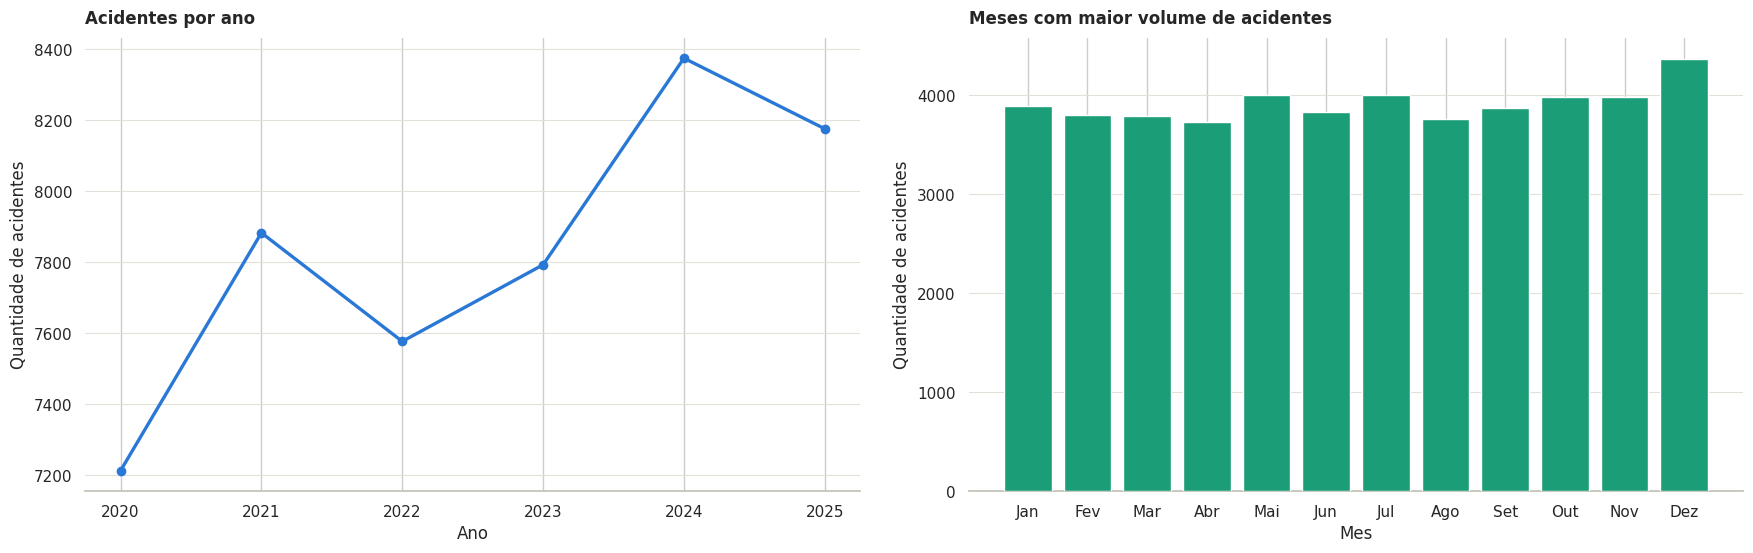

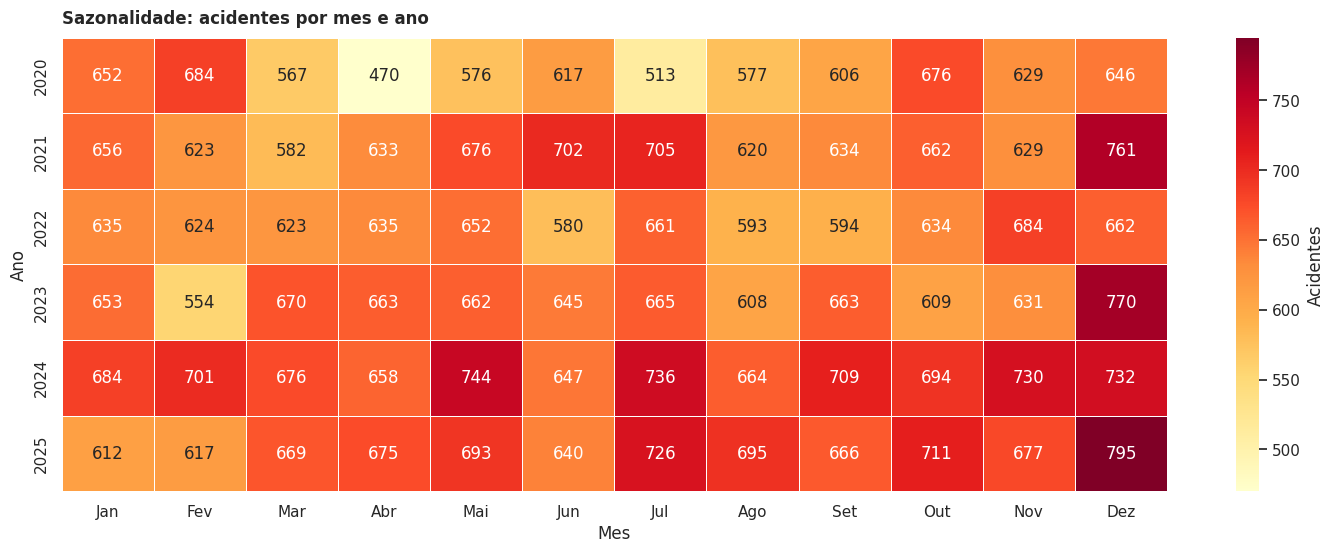

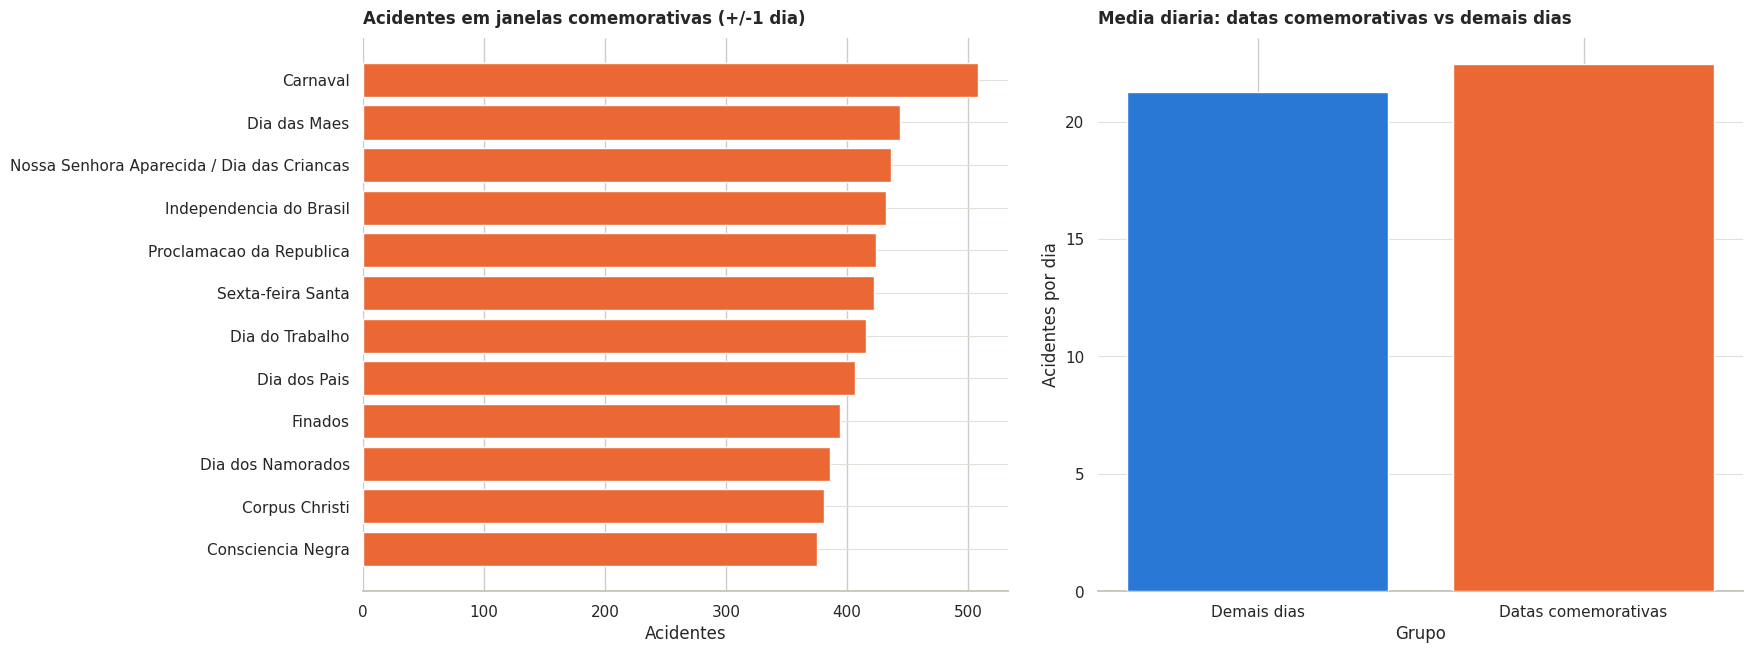

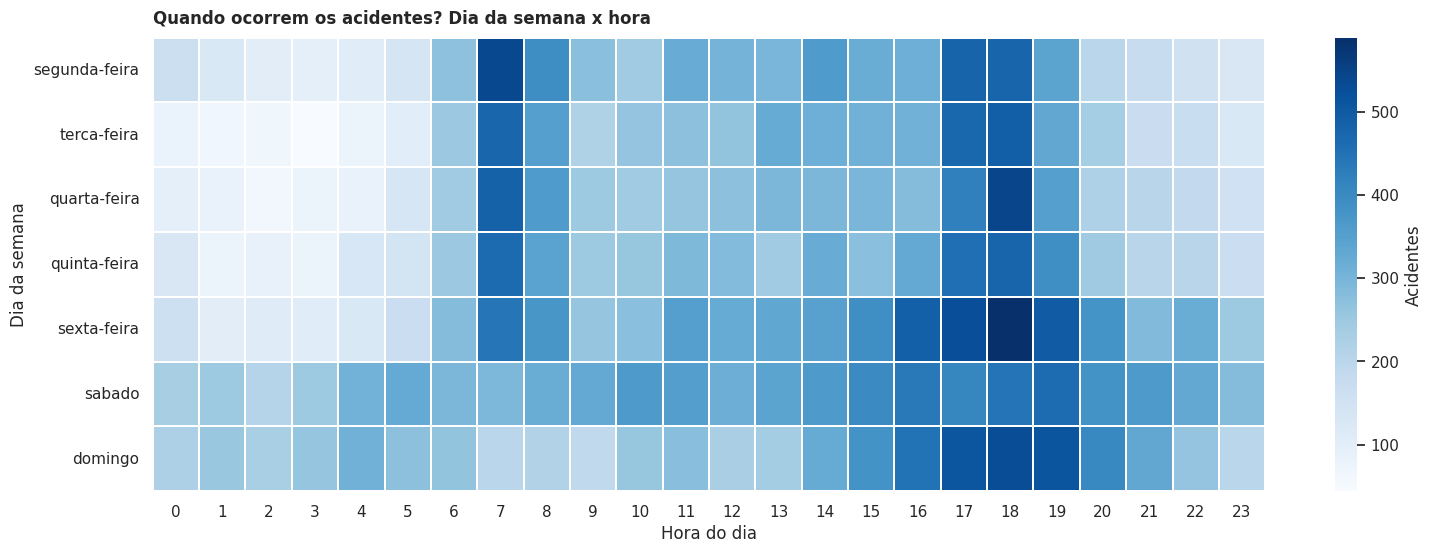

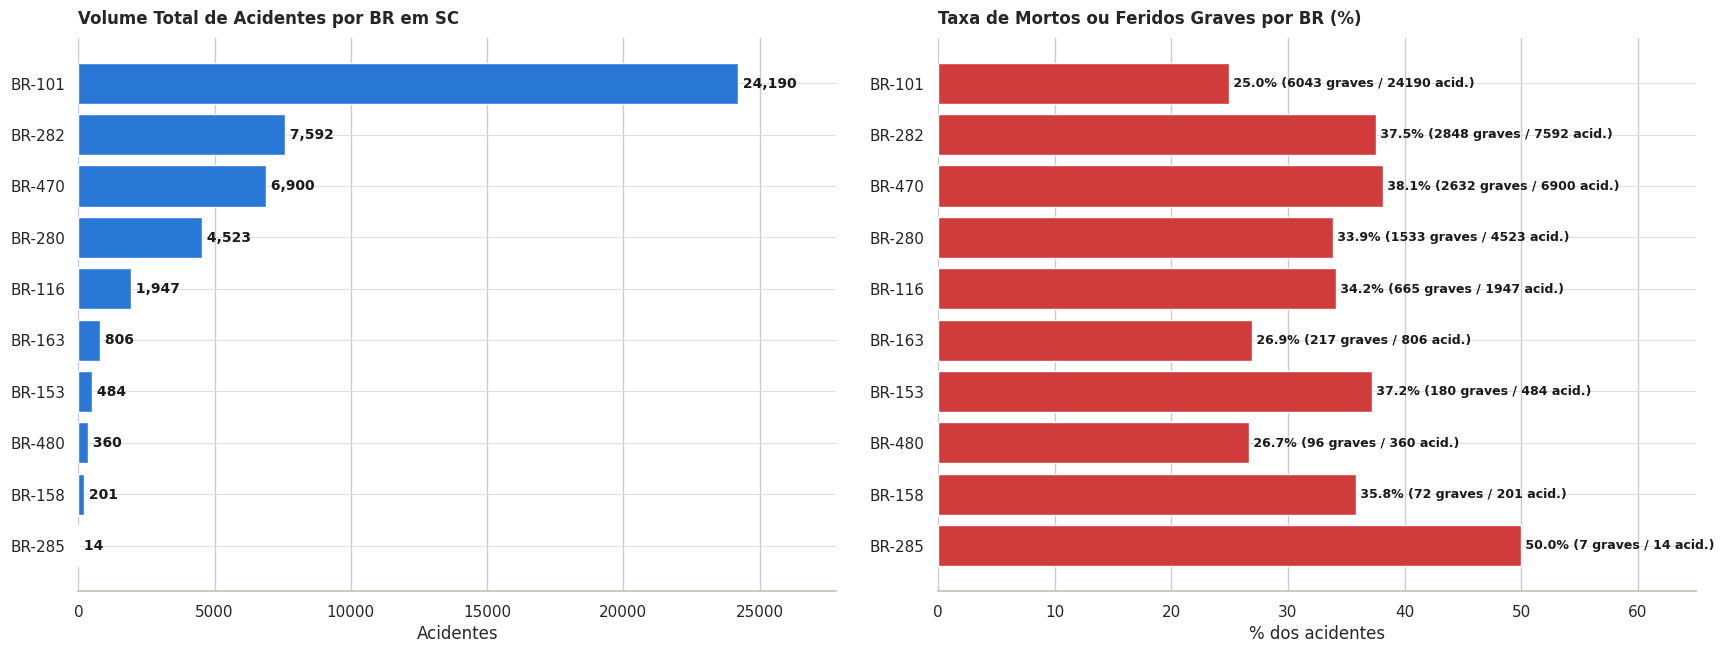

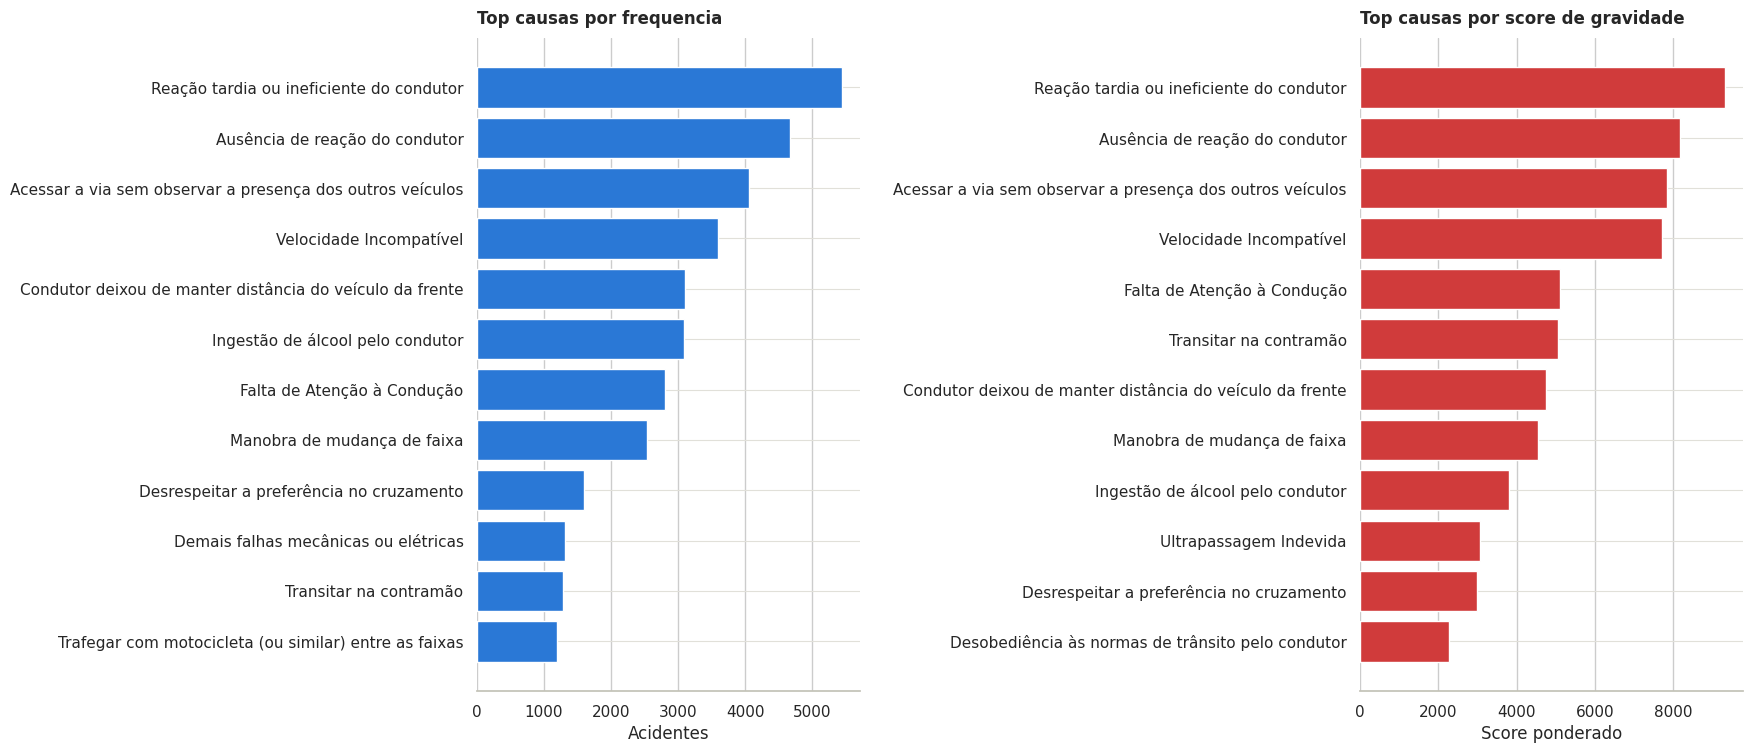

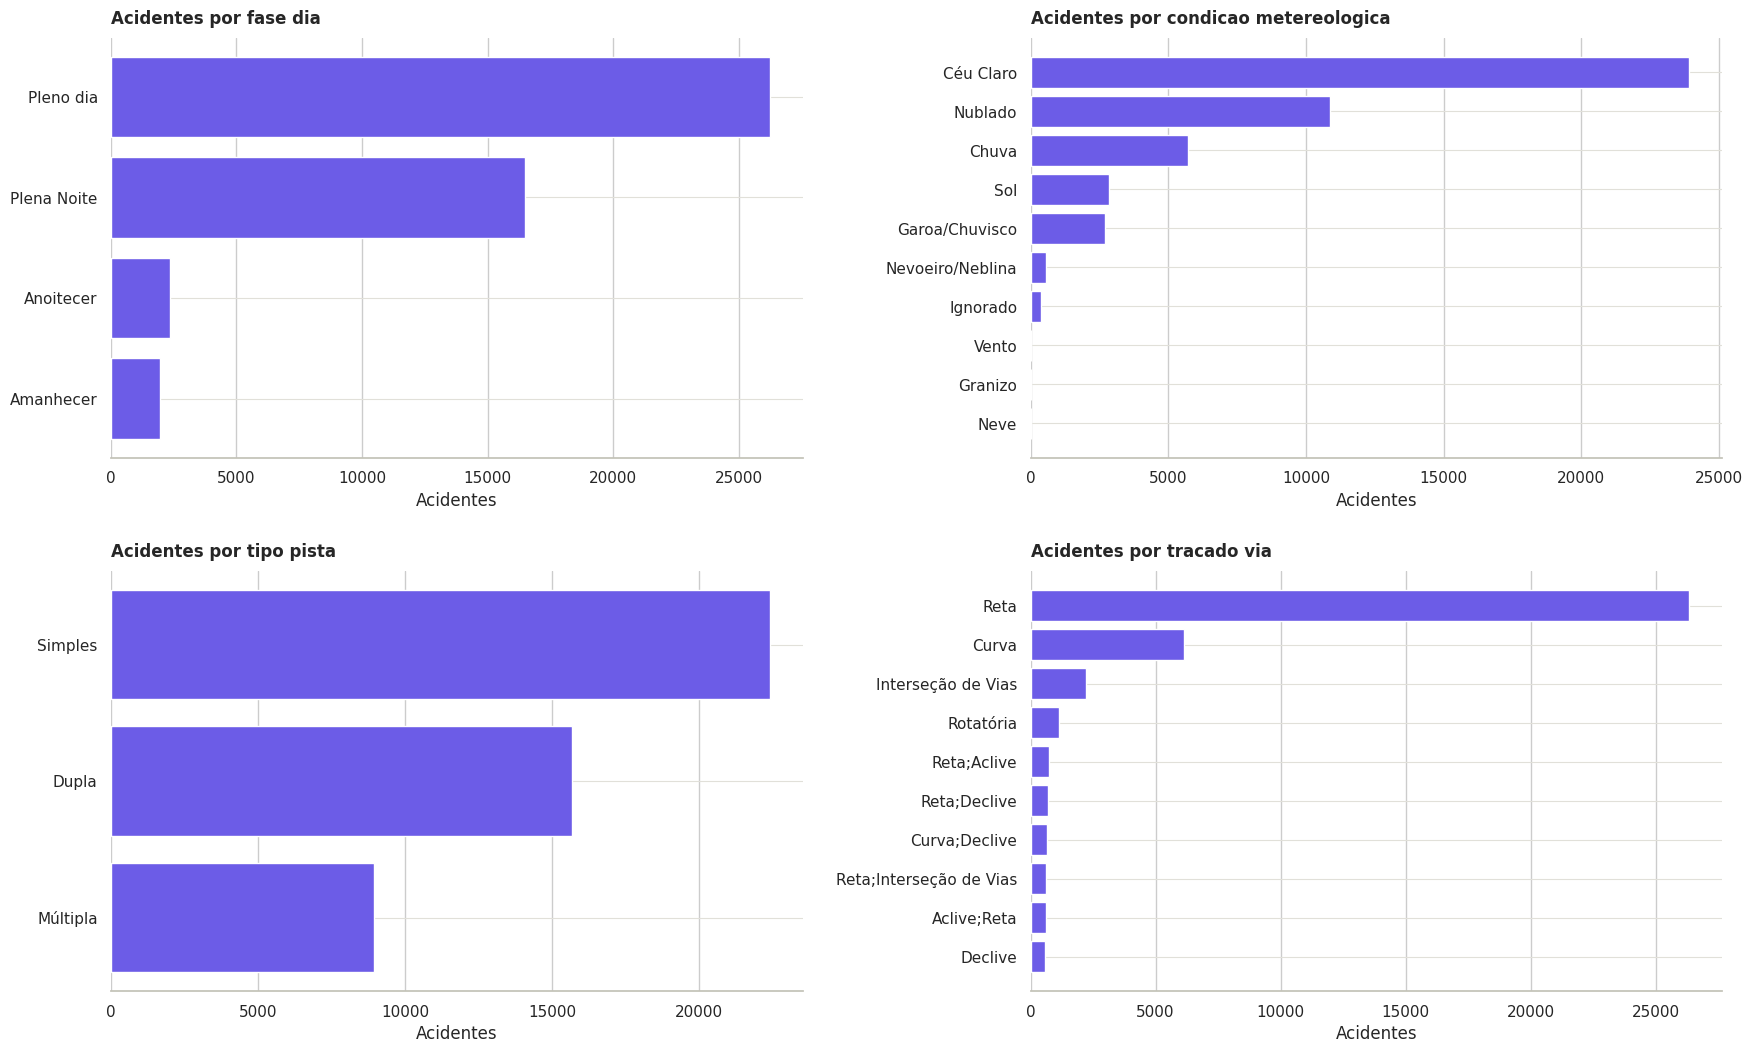

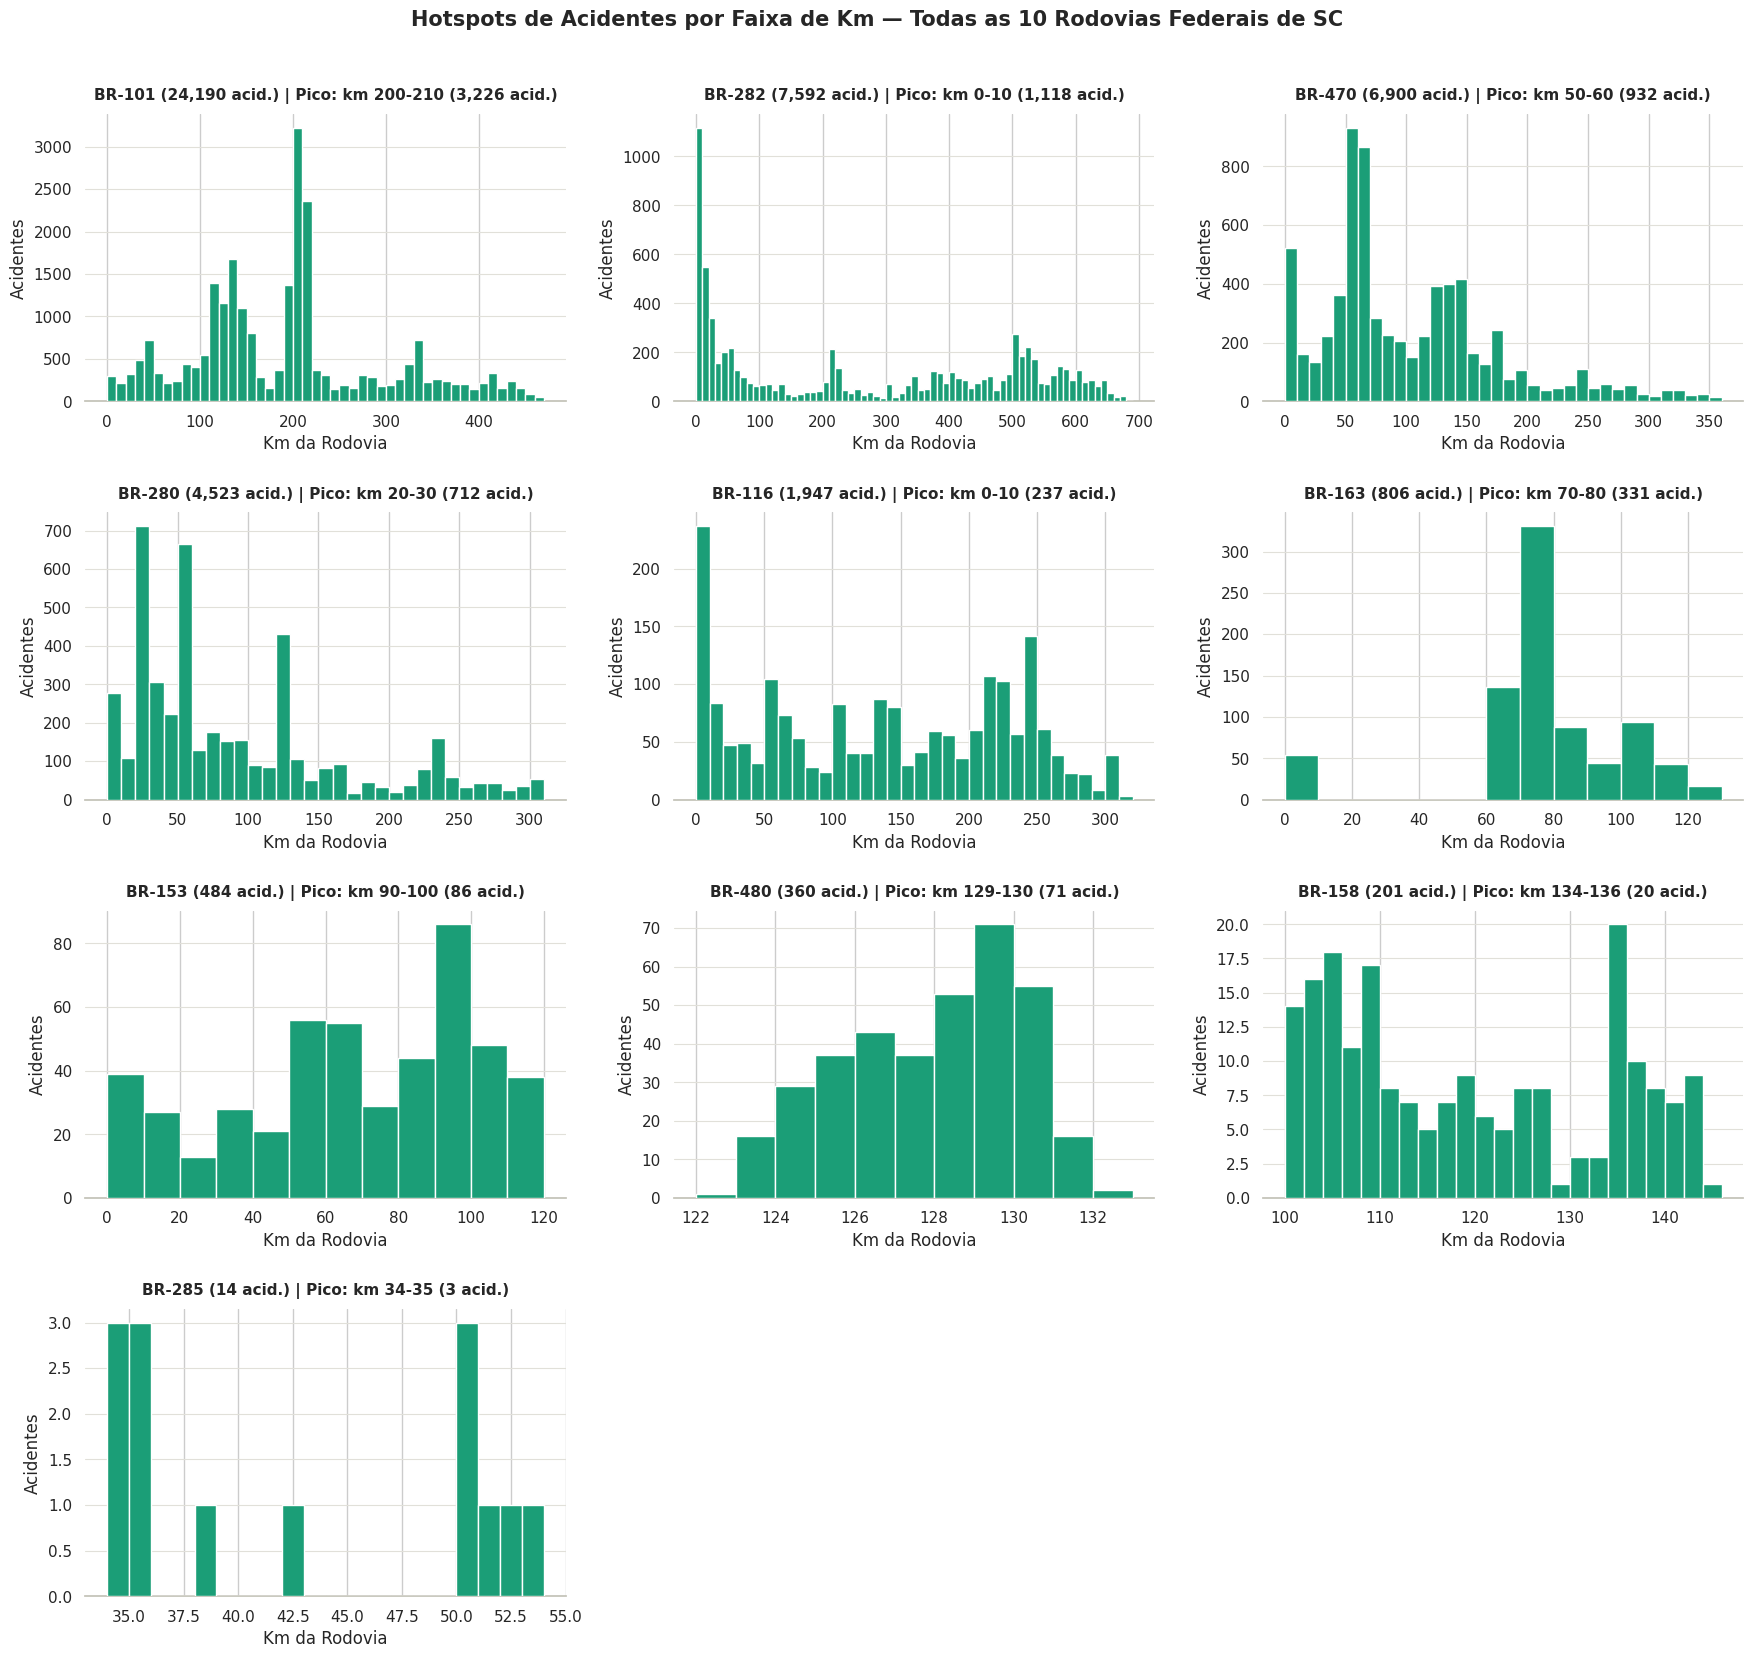

In [ ]:
import calendar
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# Paleta fixa e discreta para manter consistencia visual.
sns.set_theme(style="whitegrid", context="notebook")
COLOR_BLUE = "#2a78d6"
COLOR_TEAL = "#1b9e77"
COLOR_ORANGE = "#eb6834"
COLOR_PURPLE = "#6c5ce7"
COLOR_GOOD = "#2e9f50"
COLOR_WARNING = "#f2b84b"
COLOR_SERIOUS = "#ec835a"
COLOR_CRITICAL = "#d03b3b"
GRID_COLOR = "#e1e0d9"

DIAS_ORDEM = [
    "segunda-feira", "terca-feira", "quarta-feira", "quinta-feira",
    "sexta-feira", "sabado", "domingo",
]
MESES_ORDEM = list(range(1, 13))
MESES_LABEL = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]


def _style_ax(ax, title: str, xlabel: str | None = None, ylabel: str | None = None) -> None:
    ax.set_title(title, fontsize=12, loc="left", pad=10, fontweight="bold")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)


def _finish(fig) -> None:
    fig.tight_layout(pad=2.0)
    plt.show()


def _easter_date(year: int) -> pd.Timestamp:
    """Calcula a Pascoa pelo algoritmo Meeus/Jones/Butcher."""
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(year=year, month=month, day=day)


def _nth_weekday(year: int, month: int, weekday: int, n: int) -> pd.Timestamp:
    days = [
        day for day in range(1, calendar.monthrange(year, month)[1] + 1)
        if pd.Timestamp(year=year, month=month, day=day).weekday() == weekday
    ]
    return pd.Timestamp(year=year, month=month, day=days[n - 1])


def build_calendar_events(years: list[int]) -> dict[pd.Timestamp, str]:
    """Datas nacionais e comemorativas populares; nao mede causalidade, apenas associacao temporal."""
    events: dict[pd.Timestamp, str] = {}
    for year in years:
        easter = _easter_date(year)
        fixed = {
            (1, 1): "Ano Novo",
            (4, 21): "Tiradentes",
            (5, 1): "Dia do Trabalho",
            (6, 12): "Dia dos Namorados",
            (6, 24): "Sao Joao",
            (9, 7): "Independencia do Brasil",
            (10, 12): "Nossa Senhora Aparecida / Dia das Criancas",
            (11, 2): "Finados",
            (11, 15): "Proclamacao da Republica",
            (11, 20): "Consciencia Negra",
            (12, 24): "Vespera de Natal",
            (12, 25): "Natal",
            (12, 31): "Vespera de Ano Novo",
        }
        for (month, day), name in fixed.items():
            events[pd.Timestamp(year=year, month=month, day=day)] = name

        variable = {
            easter - pd.Timedelta(days=48): "Carnaval",
            easter - pd.Timedelta(days=47): "Carnaval",
            easter - pd.Timedelta(days=2): "Sexta-feira Santa",
            easter: "Pascoa",
            easter + pd.Timedelta(days=60): "Corpus Christi",
            _nth_weekday(year, 5, 6, 2): "Dia das Maes",
            _nth_weekday(year, 8, 6, 2): "Dia dos Pais",
        }
        events.update(variable)
    return events


def _nearest_event_name(date: pd.Timestamp, events: dict[pd.Timestamp, str], window_days: int = 1) -> str:
    best_name = "Fora de datas comemorativas"
    best_distance = window_days + 1
    for offset in range(-window_days, window_days + 1):
        candidate = date + pd.Timedelta(days=offset)
        if candidate in events and abs(offset) < best_distance:
            best_name = events[candidate]
            best_distance = abs(offset)
    return best_name


def prepare_eda(df: pd.DataFrame) -> pd.DataFrame:
    eda = df.copy()

    eda["data"] = pd.to_datetime(eda["data_inversa"], errors="coerce")
    eda = eda.dropna(subset=["data"]).copy()
    eda["ano"] = eda["data"].dt.year
    eda["mes"] = eda["data"].dt.month
    eda["mes_nome"] = pd.Categorical(eda["mes"].map(dict(zip(MESES_ORDEM, MESES_LABEL))), MESES_LABEL, ordered=True)
    eda["dia_mes"] = eda["data"].dt.day
    eda["fim_de_semana"] = eda["data"].dt.weekday >= 5

    if "dia_semana" in eda.columns:
        dia_norm = (
            eda["dia_semana"].astype(str).str.lower().str.strip()
            .str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")
        )
        eda["dia_semana_norm"] = pd.Categorical(dia_norm, DIAS_ORDEM, ordered=True)

    if "horario" in eda.columns:
        eda["hora"] = pd.to_datetime(eda["horario"], format="%H:%M:%S", errors="coerce").dt.hour

    for col in ["br", "km", "pessoas", "mortos", "feridos", "feridos_leves", "feridos_graves", "ilesos", "veiculos"]:
        if col in eda.columns:
            eda[col] = pd.to_numeric(
                eda[col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce",
            )

    for col in ["mortos", "feridos", "feridos_leves", "feridos_graves", "ilesos"]:
        if col not in eda.columns:
            eda[col] = 0
        eda[col] = eda[col].fillna(0)

    eda["vitimas"] = eda["mortos"] + eda["feridos"]
    eda["gravidade_score"] = eda["mortos"] * 5 + eda["feridos_graves"] * 3 + eda["feridos_leves"]
    eda["teve_morte"] = eda["mortos"].gt(0)
    eda["teve_ferido_grave"] = eda["feridos_graves"].gt(0)

    events = build_calendar_events(sorted(eda["ano"].dropna().astype(int).unique()))
    eda["data_comemorativa_exata"] = eda["data"].map(events).fillna("Fora de datas comemorativas")
    eda["periodo_comemorativo"] = eda["data"].map(lambda date: _nearest_event_name(date, events, window_days=1))
    eda["em_periodo_comemorativo"] = eda["periodo_comemorativo"].ne("Fora de datas comemorativas")
    return eda


def daily_calendar_rates(eda: pd.DataFrame) -> pd.DataFrame:
    date_range = pd.date_range(eda["data"].min().normalize(), eda["data"].max().normalize(), freq="D")
    events = build_calendar_events(sorted(pd.Series(date_range.year).unique()))
    calendar_df = pd.DataFrame({"data": date_range})
    calendar_df["periodo_comemorativo"] = calendar_df["data"].map(lambda date: _nearest_event_name(date, events, window_days=1))
    calendar_df["em_periodo_comemorativo"] = calendar_df["periodo_comemorativo"].ne("Fora de datas comemorativas")

    daily_counts = eda.groupby("data").size().rename("acidentes").reset_index()
    daily = calendar_df.merge(daily_counts, on="data", how="left")
    daily["acidentes"] = daily["acidentes"].fillna(0)
    return daily


def print_eda_insights(eda: pd.DataFrame) -> None:
    print("INSIGHTS RAPIDOS PARA A EDA E MODELAGEM")
    print("=" * 48)
    print(f"Periodo analisado: {eda['data'].min().date()} a {eda['data'].max().date()} | {len(eda):,} acidentes")

    mes_top = eda["mes_nome"].value_counts().reindex(MESES_LABEL).idxmax()
    mes_qtd = int(eda["mes_nome"].value_counts().reindex(MESES_LABEL).max())
    print(f"- Mes com mais acidentes no volume total: {mes_top} ({mes_qtd:,} registros).")

    if {"dia_semana_norm", "hora"}.issubset(eda.columns):
        heat = eda.dropna(subset=["dia_semana_norm", "hora"]).groupby(["dia_semana_norm", "hora"], observed=False).size()
        if not heat.empty:
            top_day, top_hour = heat.idxmax()
            print(f"- Combinacao dia-hora mais frequente: {top_day}, {int(top_hour):02d}h ({int(heat.max()):,} acidentes).")

    daily = daily_calendar_rates(eda)
    rates = daily.groupby("em_periodo_comemorativo")["acidentes"].mean()
    if {False, True}.issubset(set(rates.index)):
        ratio = rates.loc[True] / rates.loc[False] if rates.loc[False] else np.nan
        print(
            "- Media diaria em janela comemorativa (+/-1 dia): "
            f"{rates.loc[True]:.1f} contra {rates.loc[False]:.1f} fora dessas datas "
            f"(razao {ratio:.2f}x)."
        )

    event_rates = (
        daily[daily["em_periodo_comemorativo"]]
        .groupby("periodo_comemorativo")
        .agg(dias=("data", "count"), acidentes=("acidentes", "sum"), media_diaria=("acidentes", "mean"))
        .query("dias >= 3")
        .sort_values(["media_diaria", "acidentes"], ascending=False)
    )
    if not event_rates.empty:
        top_event = event_rates.index[0]
        print(f"- Data comemorativa com maior media diaria: {top_event} ({event_rates.iloc[0]['media_diaria']:.1f} acidentes/dia).")

    if "causa_acidente" in eda.columns:
        top_causa_grave = (
            eda.groupby("causa_acidente")["gravidade_score"]
            .sum().sort_values(ascending=False).head(1)
        )
        if not top_causa_grave.empty:
            print(f"- Causa com maior score de gravidade: {top_causa_grave.index[0]} ({top_causa_grave.iloc[0]:.0f} pontos).")

    print("\nSugestoes de graficos/insights extras para decidir se entram no trabalho:")
    print("1. Normalizar acidentes por dia do mes/ano para comparar feriados sem enviesar por quantidade de dias comuns.")
    print("2. Criar alvo de modelo: acidente grave = mortos > 0 ou feridos_graves > 0; comparar taxa por clima, horario, BR e fase do dia.")
    print("3. Mapear hotspots por BR e faixas de km, especialmente nas BRs com maior volume.")
    print("4. Usar interacoes dia_semana x hora e mes x ano como evidencias de sazonalidade para features do modelo.")
    print("5. Comparar causa_acidente e tipo_acidente por gravidade, nao apenas por frequencia.")


def plot_eda_dashboard(eda: pd.DataFrame) -> None:
    if eda.empty:
        print("Base vazia - nada para plotar.")
        return

    print_eda_insights(eda)

    # 1) Tendencia anual e sazonalidade mensal.
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    por_ano = eda.groupby("ano").size().sort_index()
    axes[0].plot(por_ano.index, por_ano.values, color=COLOR_BLUE, marker="o", linewidth=2.4, zorder=3)
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    _style_ax(axes[0], "Acidentes por ano", "Ano", "Quantidade de acidentes")

    por_mes = eda["mes_nome"].value_counts().reindex(MESES_LABEL).fillna(0)
    axes[1].bar(por_mes.index, por_mes.values, color=COLOR_TEAL, zorder=3)
    _style_ax(axes[1], "Meses com maior volume de acidentes", "Mes", "Quantidade de acidentes")
    _finish(fig)

    # 2) Mes x ano: mostra se os meses criticos se repetem ou se sao pontuais.
    fig, ax = plt.subplots(figsize=(15, 6))
    matriz_mes_ano = (
        eda.pivot_table(index="ano", columns="mes", values="id", aggfunc="count", fill_value=0)
        .reindex(columns=MESES_ORDEM, fill_value=0)
    )
    sns.heatmap(matriz_mes_ano, cmap="YlOrRd", linewidths=0.5, annot=True, fmt=".0f", cbar_kws={"label": "Acidentes"}, ax=ax)
    ax.set_xticklabels(MESES_LABEL, rotation=0)
    ax.set_title("Sazonalidade: acidentes por mes e ano", loc="left", pad=10, fontweight="bold")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Ano")
    _finish(fig)

    # 3) Datas comemorativas: volume bruto e comparacao justa por media diaria.
    daily = daily_calendar_rates(eda)
    event_summary = (
        daily[daily["em_periodo_comemorativo"]]
        .groupby("periodo_comemorativo")
        .agg(dias=("data", "count"), acidentes=("acidentes", "sum"), media_diaria=("acidentes", "mean"))
        .sort_values("acidentes", ascending=False)
        .head(12)
        .sort_values("acidentes")
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    if not event_summary.empty:
        axes[0].barh(event_summary.index, event_summary["acidentes"], color=COLOR_ORANGE, zorder=3)
        _style_ax(axes[0], "Acidentes em janelas comemorativas (+/-1 dia)", "Acidentes", "")
    else:
        axes[0].text(0.5, 0.5, "Sem datas comemorativas na base", ha="center", va="center", transform=axes[0].transAxes)
        _style_ax(axes[0], "Acidentes em janelas comemorativas (+/-1 dia)")

    rate_summary = (
        daily.assign(grupo=np.where(daily["em_periodo_comemorativo"], "Datas comemorativas", "Demais dias"))
        .groupby("grupo")["acidentes"].mean()
        .reindex(["Demais dias", "Datas comemorativas"])
    )
    axes[1].bar(rate_summary.index, rate_summary.values, color=[COLOR_BLUE, COLOR_ORANGE], zorder=3)
    _style_ax(axes[1], "Media diaria: datas comemorativas vs demais dias", "Grupo", "Acidentes por dia")
    _finish(fig)

    # 4) Padrao operacional: dia da semana x hora.
    if {"dia_semana_norm", "hora"}.issubset(eda.columns):
        fig, ax = plt.subplots(figsize=(16, 6))
        matriz_dia_hora = (
            eda.dropna(subset=["dia_semana_norm", "hora"])
            .pivot_table(index="dia_semana_norm", columns="hora", values="id", aggfunc="count", fill_value=0, observed=False)
            .reindex(index=DIAS_ORDEM)
            .reindex(columns=range(24), fill_value=0)
        )
        sns.heatmap(matriz_dia_hora, cmap="Blues", linewidths=0.25, cbar_kws={"label": "Acidentes"}, ax=ax)
        ax.set_title("Quando ocorrem os acidentes? Dia da semana x hora", loc="left", pad=10, fontweight="bold")
        ax.set_xlabel("Hora do dia")
        ax.set_ylabel("Dia da semana")
        _finish(fig)

    # 5) Severidade por BR e taxa de acidentes graves.
    if "br" in eda.columns:
        br_summary = (
            eda.dropna(subset=["br"])
            .loc[lambda df: df["br"].isin(BRS_VALIDAS_SC)]
            .groupby("br")
            .agg(acidentes=("id", "count"), mortos=("mortos", "sum"), feridos_graves=("feridos_graves", "sum"), gravidade=("gravidade_score", "sum"))
            .assign(taxa_grave=lambda x: (x["mortos"] + x["feridos_graves"]) / x["acidentes"])
            .sort_values("acidentes", ascending=True)
        )
        br_summary["graves"] = br_summary["mortos"] + br_summary["feridos_graves"]
        br_labels = [f"BR-{int(br)}" for br in br_summary.index]

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        # 1. Volume de acidentes com anotação explícita
        bars0 = axes[0].barh(br_labels, br_summary["acidentes"], color=COLOR_BLUE, zorder=3)
        _style_ax(axes[0], "Volume Total de Acidentes por BR em SC", "Acidentes", "")
        axes[0].set_xlim(0, br_summary["acidentes"].max() * 1.15)
        for bar in bars0:
            w = bar.get_width()
            axes[0].annotate(f" {int(w):,}", xy=(w, bar.get_y() + bar.get_height()/2),
                             va="center", fontsize=10, fontweight="bold", color="#1a1a1a")

        # 2. Taxa de gravidade com proporção explicada
        bars1 = axes[1].barh(br_labels, br_summary["taxa_grave"] * 100, color=COLOR_CRITICAL, zorder=3)
        _style_ax(axes[1], "Taxa de Mortos ou Feridos Graves por BR (%)", "% dos acidentes", "")
        axes[1].set_xlim(0, (br_summary["taxa_grave"] * 100).max() * 1.3)
        for bar, (_, row) in zip(bars1, br_summary.iterrows()):
            w = bar.get_width()
            axes[1].annotate(f" {w:.1f}% ({int(row['graves'])} graves / {int(row['acidentes'])} acid.)",
                             xy=(w, bar.get_y() + bar.get_height()/2),
                             va="center", fontsize=9, fontweight="bold", color="#1a1a1a")

        _finish(fig)

    # 6) Causas: frequencia versus gravidade.
    if "causa_acidente" in eda.columns:
        causa_freq = eda["causa_acidente"].value_counts().head(12).sort_values()
        causa_grav = eda.groupby("causa_acidente")["gravidade_score"].sum().sort_values(ascending=False).head(12).sort_values()
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        axes[0].barh(causa_freq.index, causa_freq.values, color=COLOR_BLUE, zorder=3)
        _style_ax(axes[0], "Top causas por frequencia", "Acidentes", "")
        axes[1].barh(causa_grav.index, causa_grav.values, color=COLOR_CRITICAL, zorder=3)
        _style_ax(axes[1], "Top causas por score de gravidade", "Score ponderado", "")
        _finish(fig)

    # 7) Condicoes externas e fase do dia.
    cols_contexto = [col for col in ["fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via"] if col in eda.columns]
    if cols_contexto:
        ncols = 2
        nrows = int(np.ceil(len(cols_contexto) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.5 * nrows))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, cols_contexto):
            serie = eda[col].fillna("Ignorado").value_counts().head(10).sort_values()
            ax.barh(serie.index, serie.values, color=COLOR_PURPLE, zorder=3)
            _style_ax(ax, f"Acidentes por {col.replace('_', ' ')}", "Acidentes", "")
        for ax in axes[len(cols_contexto):]:
            ax.axis("off")
        _finish(fig)

    # 8) Hotspots por km para todas as 9 BRs conservadas de SC.
    if {"br", "km"}.issubset(eda.columns):
        brs_ordenadas = eda["br"].dropna().value_counts().index.tolist()
        brs_plot = [br for br in brs_ordenadas if br in BRS_VALIDAS_SC]
        if not brs_plot:
            brs_plot = brs_ordenadas

        ncols = 3
        nrows = int(np.ceil(len(brs_plot) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=False)
        axes = np.array(axes).flatten()

        for idx, br in enumerate(brs_plot):
            ax = axes[idx]
            trecho = eda.loc[eda["br"].eq(br), "km"].dropna()
            if trecho.empty:
                ax.text(0.5, 0.5, "Sem km valido", ha="center", va="center", transform=ax.transAxes)
            else:
                extensao = trecho.max() - trecho.min()
                # Bins dinamicos conforme a extensao da BR (ex: BR-480 tem ~10 km, BR-101 tem 465 km)
                bin_size = 1 if extensao <= 20 else (2 if extensao <= 60 else 10)
                bins = np.arange(
                    np.floor(trecho.min() / bin_size) * bin_size,
                    np.ceil(trecho.max() / bin_size) * bin_size + bin_size,
                    bin_size
                )
                counts, edges, _ = ax.hist(trecho, bins=bins, color=COLOR_TEAL, edgecolor="white", zorder=3)
                max_idx = np.argmax(counts)
                pico_info = f"Pico: km {edges[max_idx]:.0f}-{edges[max_idx+1]:.0f} ({int(counts[max_idx]):,} acid.)"
                ax.set_title(f"BR-{int(br)} ({len(trecho):,} acid.) | {pico_info}", fontsize=11, fontweight="bold", pad=8)
            _style_ax(ax, "", "Km da Rodovia", "Acidentes")

        for ax in axes[len(brs_plot):]:
            ax.axis("off")

        fig.suptitle("Hotspots de Acidentes por Faixa de Km — Todas as 10 Rodovias Federais de SC", fontsize=15, fontweight="bold", y=0.995)
        _finish(fig)


if FINAL_OUTPUT_PATH.exists():
    _df_plot = pd.read_csv(FINAL_OUTPUT_PATH)
    _eda = prepare_eda(_df_plot)
    plot_eda_dashboard(_eda)
else:
    print(f"{FINAL_OUTPUT_PATH} nao existe ainda - rode main() primeiro.")
